In [22]:
%matplotlib inline

# Image-Only Fraud Detection - ResNet-18

This notebook evaluates an image-based fraud detection baseline using a ResNet model. Unlike the tabular models, this model uses transaction images as input. The goal is to test whether visual representations contain useful fraud-related information and to compare the image-based model with the tabular Logistic Regression and XGBoost baselines.

The evaluation follows the same logic as the tabular experiments. The model is evaluated using precision, recall, F1-score, ROC-AUC, PR-AUC, confusion matrices, threshold tuning, and expected cost.
Two experiments:
- **A_weighted** - BCEWithLogitsLoss + pos_weight
- **B_unweighted** - BCEWithLogitsLoss no weighting

Structure mirrors notebooks 19 (multimodal).
All functions from `image_baseline_utils.py` and `mm_image_utils.py`.


## 0 · Imports & reproducibility

In [23]:
import sys, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import (roc_curve, auc as sk_auc,
                             precision_recall_curve, average_precision_score)

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")


plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from image_baseline_utils import (
    build_model, unfreeze_backbone,
    fit_model, run_test_evaluation, predict_probs,
    compute_metrics, tune_threshold,
    build_train_transform, build_val_transform,
    GradCAM,
)
from mm_image_utils import (
    load_mm_splits, build_mm_dataloaders,
    make_loss_fn, subgroup_by_combo,
)

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

SEED   = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}  |  PyTorch {torch.__version__}")


Device : cpu  |  PyTorch 2.11.0+cpu


## 1 · Config

In [24]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

BACKBONE = "resnet18"

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE  = 32
NUM_WORKERS = 0
STAGE1_EPOCHS   = 5;  STAGE1_LR = 1e-3;  STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20; BACKBONE_LR = 1e-5; HEAD_LR = 1e-4; STAGE2_PATIENCE = 6
DROPOUT = 0.3

RESULTS_BASE = PROJECT_ROOT / "notebook" / "results" / f"mm_image_{BACKBONE}"
EXP_DIRS = {
    "A_weighted":   RESULTS_BASE / "A_weighted",
    "B_unweighted": RESULTS_BASE / "B_unweighted",
}
for d in EXP_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print(f"Backbone    : {BACKBONE}")
print(f"Results base: {RESULTS_BASE}")

COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}


Backbone    : resnet18
Results base: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18


## 2 · Load data

In [25]:
from torch import nn

train_df, val_df, test_df = load_mm_splits(TRAIN_CSV, VAL_CSV, TEST_CSV)

train_loader, val_loader, test_loader = build_mm_dataloaders(
    train_df, val_df, test_df,
    train_transform=build_train_transform(),
    val_transform=build_val_transform(),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=False,
)
print(f"Batches — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")

LOSS_FNS = {
    "A_weighted":   make_loss_fn(train_df, device),      # pos_weight
    "B_unweighted": nn.BCEWithLogitsLoss().to(device),   # no weighting
}
print("Loss functions ready:", list(LOSS_FNS))


train: 7,182 rows | label 0:2,588 label 1:4,594 ratio 1:1.78
  combos: {'tab0_img0': 2588, 'tab0_img1': 1866, 'tab1_img0': 863, 'tab1_img1': 1865}
val: 1,508 rows | label 0:557 label 1:951 ratio 1:1.71
  combos: {'tab0_img0': 557, 'tab0_img1': 382, 'tab1_img0': 186, 'tab1_img1': 383}
test: 1,474 rows | label 0:554 label 1:920 ratio 1:1.66
  combos: {'tab0_img0': 554, 'tab0_img1': 368, 'tab1_img0': 185, 'tab1_img1': 367}
Batches — train:225 val:48 test:47
  pos_weight = 0.563  (n_neg=2588, n_pos=4594)  [DOWN-weighting fraud (majority)]
Loss functions ready: ['A_weighted', 'B_unweighted']


## 3 · Dataset imbalance analysis
Mirrors the multimodal notebook — shows why weighted loss matters.


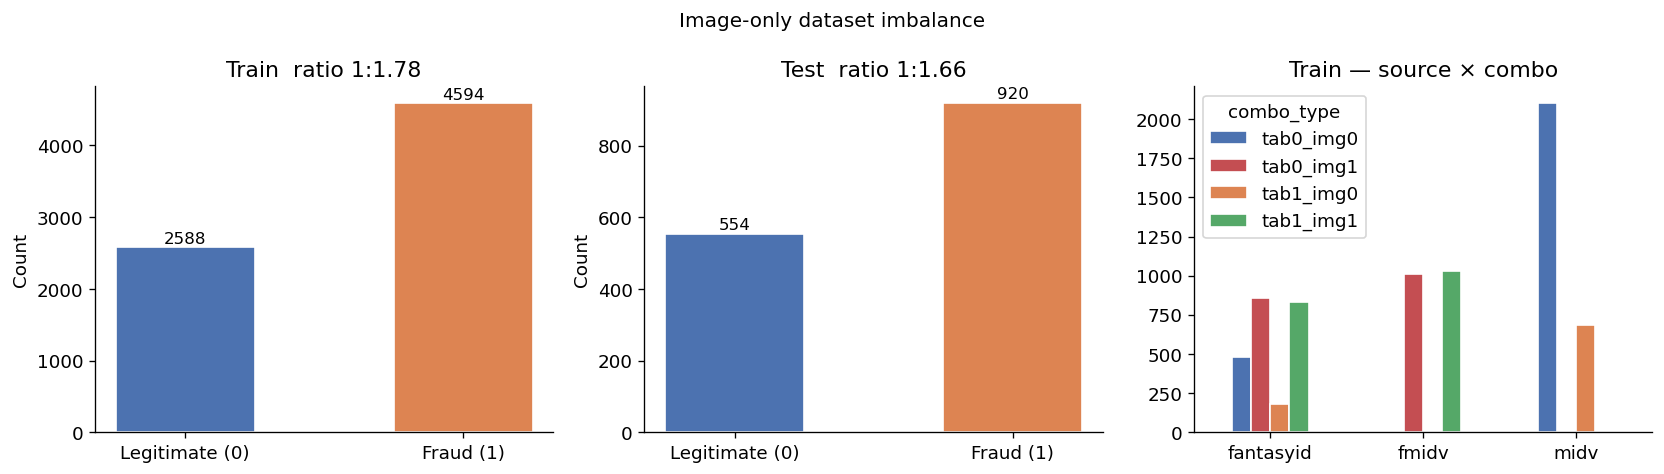

pos_weight = 2588/4594 = 0.563


In [26]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df) in zip(axes[:2], [("Train", train_df), ("Test", test_df)]):
    counts = df["final_label"].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)", "Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0) / max(counts.get(0,1), 1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}"); ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)

if "img_source_dataset" in train_df.columns:
    pd.crosstab(train_df["img_source_dataset"],
                train_df["combo_type"]).plot(
        kind="bar", ax=axes[2],
        color=list(COMBO_COLOURS.values()), edgecolor="white")
    axes[2].set_title("Train — source × combo")
    axes[2].set_xlabel(""); axes[2].tick_params(axis="x", rotation=0)
    axes[2].spines[["top","right"]].set_visible(False)

fig.suptitle("Image-only dataset imbalance", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "imbalance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

n0 = (train_df["final_label"]==0).sum()
n1 = (train_df["final_label"]==1).sum()
print(f"pos_weight = {n0}/{n1} = {n0/n1:.3f}")


The image-only dataset has a much more balanced class distribution than the full tabular dataset. Fraud cases are more common than legitimate cases, with a train ratio of approximately 1:1.78 and a test ratio of approximately 1:1.66. This means that the image-based experiment is not directly comparable to the full tabular setting in terms of class imbalance. The source-combination distribution also shows that the dataset is unevenly distributed across image sources and class combinations, which may influence what the ResNet model learns. 

Therefore, the image-only results should be interpreted as a separate baseline rather than a direct replacement for the full tabular models.

## 4 · Training helper

In [27]:
import json
import numpy as np
import pandas as pd
import torch


def json_safe(obj):
    """
    Convert numpy / torch objects into JSON-safe Python objects.
    """
    if isinstance(obj, dict):
        return {k: json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj


def load_cached_image_results(exp_id, results_dir):
    """
    Load saved image-model evaluation outputs without retraining or reevaluating.
    """
    print(f"\nSaved evaluation outputs found for {exp_id} — loading cached results.")

    pred_df = pd.read_csv(results_dir / "test_predictions.csv")
    sg = pd.read_csv(results_dir / "subgroup_combo_type.csv")
    sweep_df = pd.read_csv(results_dir / "threshold_sweep.csv")

    with open(results_dir / "test_metrics.json", "r") as f:
        test_metrics = json.load(f)

    with open(results_dir / "threshold_summary.json", "r") as f:
        threshold_summary = json.load(f)

    best_t = float(threshold_summary["best_threshold"])

    y_true = pred_df["y_true"].values
    y_prob = pred_df["y_prob"].values

    def get_f1(combo):
        r = sg[sg["combo_type"] == combo]
        return r["f1"].values[0] if len(r) > 0 else float("nan")

    print(f"Best threshold (cached): {best_t:.2f}")

    print("\nCached test metrics:")
    for k, v in test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"  {k:12s}: {v:.4f}")

    print(f"  tab0_img0 F1 : {get_f1('tab0_img0'):.3f}  (expected 0.000 — no image signal)")
    print(f"  tab1_img0 F1 : {get_f1('tab1_img0'):.3f}  (hard case — tab fraud, normal img)")

    return {
        "id": exp_id,
        "label": exp_id,
        "threshold": best_t,
        "metrics": test_metrics,
        "pred_df": pred_df,
        "sg": sg,
        "sweep_df": sweep_df,
        "y_true": y_true,
        "y_prob": y_prob,
    }


def run_experiment(exp_id, force_retrain=False, force_reevaluate=False):
    """
    Two-stage train + evaluation for one experiment.

    If saved evaluation outputs exist, load them instead of retraining
    or rerunning evaluation.

    force_retrain=True:
        retrain Stage 1 and Stage 2.

    force_reevaluate=True:
        skip retraining if model checkpoints exist, but rerun threshold tuning
        and test evaluation.
    """
    results_dir = EXP_DIRS[exp_id]
    loss_fn = LOSS_FNS[exp_id]
    results_dir.mkdir(parents=True, exist_ok=True)

    cache_files = [
        results_dir / "test_predictions.csv",
        results_dir / "subgroup_combo_type.csv",
        results_dir / "threshold_sweep.csv",
        results_dir / "test_metrics.json",
        results_dir / "threshold_summary.json",
    ]

    cache_exists = all(p.exists() for p in cache_files)

    if cache_exists and not force_retrain and not force_reevaluate:
        return load_cached_image_results(exp_id, results_dir)

    print(f"\n{'='*60}")
    print(f"EXPERIMENT {exp_id}")
    print(f"  backbone : {BACKBONE}")
    print(f"  dropout  : {DROPOUT}")
    print(f"  loss     : {type(loss_fn).__name__}")
    print(f"{'='*60}")

    # --------------------------------------------------
    # Stage 1 — frozen backbone
    # --------------------------------------------------
    h_s1 = None

    if (results_dir / "stage1_best.pt").exists() and not force_retrain:
        print("Stage 1 already trained — loading.")
        model = build_model(
            pretrained=False,
            freeze_backbone=True,
            dropout=DROPOUT
        ).to(device)

        model.load_state_dict(
            torch.load(results_dir / "stage1_best.pt", map_location=device)
        )

    else:
        print("Training Stage 1...")

        model = build_model(
            pretrained=True,
            freeze_backbone=True,
            dropout=DROPOUT
        ).to(device)

        opt1 = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=STAGE1_LR,
            weight_decay=1e-4
        )

        model, h_s1 = fit_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            loss_fn=loss_fn,
            optimizer=opt1,
            device=device,
            epochs=STAGE1_EPOCHS,
            early_stopping_patience=STAGE1_PATIENCE,
            monitor_metric="val_roc_auc",
            model_save_path=results_dir / "stage1_best.pt",
        )

        display(h_s1.round(4))

    # --------------------------------------------------
    # Stage 2 — full fine-tuning
    # --------------------------------------------------
    if (results_dir / "stage2_best.pt").exists() and not force_retrain:
        print("Stage 2 already trained — loading.")
        unfreeze_backbone(model)

        model.load_state_dict(
            torch.load(results_dir / "stage2_best.pt", map_location=device)
        )

    else:
        print("Training Stage 2...")

        unfreeze_backbone(model)

        bp = [p for n, p in model.named_parameters() if "fc" not in n]
        hp = list(model.fc.parameters())

        opt2 = torch.optim.Adam(
            [
                {"params": bp, "lr": BACKBONE_LR},
                {"params": hp, "lr": HEAD_LR},
            ],
            weight_decay=1e-4
        )

        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt2,
            T_max=STAGE2_EPOCHS,
            eta_min=1e-7
        )

        model, h_s2 = fit_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            loss_fn=loss_fn,
            optimizer=opt2,
            device=device,
            epochs=STAGE2_EPOCHS,
            early_stopping_patience=STAGE2_PATIENCE,
            monitor_metric="val_roc_auc",
            scheduler=sched,
            model_save_path=results_dir / "stage2_best.pt",
        )

        hist = (
            pd.concat([h_s1, h_s2], ignore_index=True)
            if h_s1 is not None
            else h_s2.copy()
        )

        hist["epoch_global"] = range(1, len(hist) + 1)
        hist.to_csv(results_dir / "training_history.csv", index=False)

        display(h_s2.round(4))

    model.eval()

    # --------------------------------------------------
    # Threshold tuning on validation set
    # --------------------------------------------------
    val_y, val_p = predict_probs(model, val_loader, device)

    best_t, sweep_df = tune_threshold(
        val_y,
        val_p,
        metric="f1"
    )

    sweep_df.to_csv(results_dir / "threshold_sweep.csv", index=False)

    with open(results_dir / "threshold_summary.json", "w") as f:
        json.dump(
            {
                "best_threshold": float(best_t),
                "selection_metric": "f1",
            },
            f,
            indent=2
        )

    # --------------------------------------------------
    # Test evaluation
    # --------------------------------------------------
    test_metrics = run_test_evaluation(
        model=model,
        test_loader=test_loader,
        loss_fn=loss_fn,
        device=device,
        threshold=best_t
    )

    with open(results_dir / "test_metrics.json", "w") as f:
        json.dump(json_safe(test_metrics), f, indent=2)

    # --------------------------------------------------
    # Save test predictions
    # --------------------------------------------------
    y_true, y_prob = predict_probs(model, test_loader, device)

    pred_df = test_df.reset_index(drop=True).copy()
    pred_df["y_true"] = y_true
    pred_df["y_prob"] = y_prob
    pred_df["y_pred"] = (pred_df["y_prob"] >= best_t).astype(int)

    pred_df.to_csv(results_dir / "test_predictions.csv", index=False)

    # --------------------------------------------------
    # Subgroup analysis
    # --------------------------------------------------
    sg = subgroup_by_combo(pred_df, best_t)
    sg.to_csv(results_dir / "subgroup_combo_type.csv", index=False)

    def get_f1(combo):
        r = sg[sg["combo_type"] == combo]
        return r["f1"].values[0] if len(r) > 0 else float("nan")

    print(f"  tab0_img0 F1 : {get_f1('tab0_img0'):.3f}  (expected 0.000 — no image signal)")
    print(f"  tab1_img0 F1 : {get_f1('tab1_img0'):.3f}  (hard case — tab fraud, normal img)")

    return {
        "id": exp_id,
        "label": exp_id,
        "threshold": best_t,
        "metrics": test_metrics,
        "pred_df": pred_df,
        "sg": sg,
        "sweep_df": sweep_df,
        "y_true": y_true,
        "y_prob": y_prob,
    }

In [28]:
res_A = run_experiment("A_weighted")
res_B = run_experiment("B_unweighted")


Saved evaluation outputs found for A_weighted — loading cached results.
Best threshold (cached): 0.35

Cached test metrics:
  threshold   : 0.3500
  accuracy    : 0.8345
  precision   : 0.8958
  recall      : 0.8315
  f1          : 0.8625
  roc_auc     : 0.8803
  loss        : 0.2904
  tab0_img0 F1 : 0.000  (expected 0.000 — no image signal)
  tab1_img0 F1 : 0.303  (hard case — tab fraud, normal img)

Saved evaluation outputs found for B_unweighted — loading cached results.
Best threshold (cached): 0.50

Cached test metrics:
  threshold   : 0.5000
  accuracy    : 0.8318
  precision   : 0.8944
  recall      : 0.8283
  f1          : 0.8600
  roc_auc     : 0.8851
  loss        : 0.3898
  tab0_img0 F1 : 0.000  (expected 0.000 — no image signal)
  tab1_img0 F1 : 0.287  (hard case — tab fraud, normal img)


In [29]:
def run_experiment(exp_id):
    """
    Two-stage train + evaluation for one experiment.
    h_s1=None pattern avoids NameError when stage 1 is cached.
    """
    results_dir = EXP_DIRS[exp_id]
    loss_fn     = LOSS_FNS[exp_id]

    print(f"\n{'='*60}")
    print(f"EXPERIMENT {exp_id}")
    print(f"  backbone : {BACKBONE}")
    print(f"  dropout  : {DROPOUT}")
    print(f"  loss     : {type(loss_fn).__name__}")
    print(f"{'='*60}")

    # Stage 1 — frozen backbone
    h_s1 = None                             
    if (results_dir / "stage1_best.pt").exists():
        print("Stage 1 already trained — skipping.")
        model = build_model(pretrained=False, freeze_backbone=True,
                            dropout=DROPOUT).to(device)
        model.load_state_dict(
            torch.load(results_dir / "stage1_best.pt", map_location=device))
    else:
        model = build_model(pretrained=True, freeze_backbone=True,
                            dropout=DROPOUT).to(device)
        opt1 = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=STAGE1_LR, weight_decay=1e-4)
        model, h_s1 = fit_model(
            model=model, train_loader=train_loader, val_loader=val_loader,
            loss_fn=loss_fn, optimizer=opt1, device=device,
            epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
            monitor_metric="val_roc_auc",
            model_save_path=results_dir / "stage1_best.pt",
        )
        display(h_s1.round(4))

    # Stage 2 — full fine-tuning
    if (results_dir / "stage2_best.pt").exists():
        print("Stage 2 already trained — skipping.")
        unfreeze_backbone(model)
        model.load_state_dict(
            torch.load(results_dir / "stage2_best.pt", map_location=device))
    else:
        unfreeze_backbone(model)
        bp = [p for n, p in model.named_parameters() if "fc" not in n]
        hp = list(model.fc.parameters())
        opt2 = torch.optim.Adam(
            [{"params": bp, "lr": BACKBONE_LR},
             {"params": hp, "lr": HEAD_LR}],
            weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
        model, h_s2 = fit_model(
            model=model, train_loader=train_loader, val_loader=val_loader,
            loss_fn=loss_fn, optimizer=opt2, device=device,
            epochs=STAGE2_EPOCHS, early_stopping_patience=STAGE2_PATIENCE,
            monitor_metric="val_roc_auc", scheduler=sched,
            model_save_path=results_dir / "stage2_best.pt",
        )
        # h_s1 may be None if stage 1 was cached — safe concat
        hist = (pd.concat([h_s1, h_s2], ignore_index=True)
                if h_s1 is not None else h_s2.copy())
        hist["epoch_global"] = range(1, len(hist) + 1)
        hist.to_csv(results_dir / "training_history.csv", index=False)
        display(h_s2.round(4))

    model.eval()

    # Threshold tuning on validation set
    val_y, val_p     = predict_probs(model, val_loader, device)
    best_t, sweep_df = tune_threshold(val_y, val_p, metric="f1")
    sweep_df.to_csv(results_dir / "threshold_sweep.csv", index=False)

    # Test evaluation
    test_metrics = run_test_evaluation(
        model=model, test_loader=test_loader,
        loss_fn=loss_fn, device=device, threshold=best_t)

    y_true, y_prob = predict_probs(model, test_loader, device)
    pred_df = test_df.reset_index(drop=True).copy()
    pred_df["y_true"] = y_true
    pred_df["y_prob"] = y_prob
    pred_df["y_pred"] = (pred_df["y_prob"] >= best_t).astype(int)
    pred_df.to_csv(results_dir / "test_predictions.csv", index=False)

    sg = subgroup_by_combo(pred_df, best_t)
    sg.to_csv(results_dir / "subgroup_combo_type.csv", index=False)

    def get_f1(combo):
        r = sg[sg["combo_type"] == combo]
        return r["f1"].values[0] if len(r) > 0 else float("nan")

    print(f"  tab0_img0 F1 : {get_f1('tab0_img0'):.3f}  (expected 0.000 — no image signal)")
    print(f"  tab1_img0 F1 : {get_f1('tab1_img0'):.3f}  (hard case — tab fraud, normal img)")

    return {"id": exp_id, "label": exp_id, "threshold": best_t,
            "metrics": test_metrics, "pred_df": pred_df,
            "sg": sg, "y_true": y_true, "y_prob": y_prob}


---
## 5 · Experiment A — Weighted loss
BCEWithLogitsLoss with pos_weight to up-weight the minority class.


In [30]:
res_A = run_experiment("A_weighted")


EXPERIMENT A_weighted
  backbone : resnet18
  dropout  : 0.3
  loss     : BCEWithLogitsLoss
Stage 1 already trained — skipping.


Stage 2 already trained — skipping.
Backbone unfrozen — all parameters now trainable.

Best threshold (f1): 0.35


KeyboardInterrupt: 

The ResNet image-only model achieved an F1-score of 0.8625 on the test set using the selected threshold of 0.35. Precision was 0.8958 and recall was 0.8315, showing that the model detects many fraud cases while keeping precision relatively high. The confusion matrix shows 765 true positives, 89 false positives, and 155 false negatives.

However, the subgroup analysis shows an important limitation. The model performs poorly on cases where the tabular data indicates fraud but the image appears normal (`tab1_img0`), with an F1-score of only 0.303. This suggests that image information alone is not enough to detect all fraud cases. Therefore, the ResNet image-only model is useful as an image baseline, but it should be combined with tabular information in the multimodal model.

---
## 6 · Experiment B - Unweighted loss
BCEWithLogitsLoss with no correction — baseline.


In [ ]:
res_B = run_experiment("B_unweighted")


EXPERIMENT B_unweighted
  backbone : resnet18
  dropout  : 0.3
  loss     : BCEWithLogitsLoss
Epoch 01 | lr=1.00e-03 | train_loss=0.5382 | val_loss=0.4634 | val_f1=0.8374 | val_roc_auc=0.8496
  ✓ Saved best model (epoch 1, val_roc_auc=0.8496)
Epoch 02 | lr=1.00e-03 | train_loss=0.4923 | val_loss=0.4510 | val_f1=0.8428 | val_roc_auc=0.8616
  ✓ Saved best model (epoch 2, val_roc_auc=0.8616)
Epoch 03 | lr=1.00e-03 | train_loss=0.4749 | val_loss=0.4550 | val_f1=0.8430 | val_roc_auc=0.8635
  ✓ Saved best model (epoch 3, val_roc_auc=0.8635)
Epoch 04 | lr=1.00e-03 | train_loss=0.4716 | val_loss=0.4378 | val_f1=0.8444 | val_roc_auc=0.8666
  ✓ Saved best model (epoch 4, val_roc_auc=0.8666)
Epoch 05 | lr=1.00e-03 | train_loss=0.4699 | val_loss=0.4433 | val_f1=0.8442 | val_roc_auc=0.8671
  ✓ Saved best model (epoch 5, val_roc_auc=0.8671)
Restored best weights (val_roc_auc=0.8671).


,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001,0.5382,0.4634,0.7845,0.7987,0.8801,0.8374,0.8496
1,2,0.001,0.4923,0.4510,0.7938,0.8113,0.8770,0.8428,0.8616
2,3,0.001,0.4749,0.4550,0.7911,0.8011,0.8896,0.8430,0.8635
3,4,0.001,0.4716,0.4378,0.8004,0.8303,0.8591,0.8444,0.8666
4,5,0.001,0.4699,0.4433,0.7951,0.8110,0.8801,0.8442,0.8671


Backbone unfrozen — all parameters now trainable.
Epoch 01 | lr=1.00e-05 | train_loss=0.4507 | val_loss=0.4103 | val_f1=0.8581 | val_roc_auc=0.8768
  ✓ Saved best model (epoch 1, val_roc_auc=0.8768)
Epoch 02 | lr=9.94e-06 | train_loss=0.4232 | val_loss=0.4050 | val_f1=0.8599 | val_roc_auc=0.8782
  ✓ Saved best model (epoch 2, val_roc_auc=0.8782)
Epoch 03 | lr=9.76e-06 | train_loss=0.4039 | val_loss=0.4018 | val_f1=0.8608 | val_roc_auc=0.8759
Epoch 04 | lr=9.46e-06 | train_loss=0.4044 | val_loss=0.4010 | val_f1=0.8579 | val_roc_auc=0.8766
Epoch 05 | lr=9.05e-06 | train_loss=0.3941 | val_loss=0.3980 | val_f1=0.8619 | val_roc_auc=0.8775
Epoch 06 | lr=8.55e-06 | train_loss=0.3970 | val_loss=0.3964 | val_f1=0.8595 | val_roc_auc=0.8766
Epoch 07 | lr=7.96e-06 | train_loss=0.3921 | val_loss=0.3960 | val_f1=0.8621 | val_roc_auc=0.8785
  ✓ Saved best model (epoch 7, val_roc_auc=0.8785)
Epoch 08 | lr=7.30e-06 | train_loss=0.3880 | val_loss=0.3980 | val_f1=0.8588 | val_roc_auc=0.8780
Epoch 09 | lr

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.4507,0.4103,0.8243,0.8745,0.8423,0.8581,0.8768
1,2,0.0,0.4232,0.4050,0.8236,0.8617,0.8580,0.8599,0.8782
2,3,0.0,0.4039,0.4018,0.8289,0.8837,0.8391,0.8608,0.8759
3,4,0.0,0.4044,0.4010,0.8256,0.8822,0.8349,0.8579,0.8766
4,5,0.0,0.3941,0.3980,0.8309,0.8884,0.8370,0.8619,0.8775
5,6,0.0,0.3970,0.3964,0.8276,0.8843,0.8360,0.8595,0.8766
6,7,0.0,0.3921,0.3960,0.8302,0.8840,0.8412,0.8621,0.8785
7,8,0.0,0.3880,0.3980,0.8236,0.8671,0.8507,0.8588,0.8780
8,9,0.0,0.3824,0.3970,0.8322,0.8886,0.8391,0.8632,0.8759
9,10,0.0,0.3818,0.3965,0.8316,0.8868,0.8402,0.8629,0.8761



Best threshold (f1): 0.50

── TEST METRICS ──────────────────────────────
  loss        : 0.3898
  accuracy    : 0.8318
  precision   : 0.8944
  recall      : 0.8283
  f1          : 0.8600
  roc_auc     : 0.8851
  confusion_matrix:
[[464  90]
 [158 762]]
──────────────────────────────────────────────
  tab0_img0 F1 : 0.000  (expected 0.000 — no image signal)
  tab1_img0 F1 : 0.287  (hard case — tab fraud, normal img)


The ResNet image-only model achieved an F1-score of 0.8600 on the test set using the selected threshold of 0.50. Precision was 0.8944 and recall was 0.8283, showing that the model detects many fraud cases while keeping precision relatively high. The confusion matrix shows 762 true positives, 90 false positives, and 158 false negatives.

However, the subgroup analysis shows that the model struggles when the fraud signal is not visible in the image. In particular, the `tab1_img0` group achieved an F1-score of only 0.287. This indicates that image-only information is not sufficient for all fraud types. Therefore, the ResNet model is useful as an image baseline, but it should be combined with tabular information in the multimodal approach.

---
## 7 · Load all results
Run this cell to reload from disk without retraining.
Mirrors `load_result()` from notebook 19.


In [ ]:
# Check all experiment folders have required files before loading
for exp_id, path in EXP_DIRS.items():
    print("\n", exp_id)
    print("Folder exists            :", path.exists())
    print("test_predictions.csv     :", (path / "test_predictions.csv").exists())
    print("subgroup_combo_type.csv  :", (path / "subgroup_combo_type.csv").exists())
    print("threshold_sweep.csv      :", (path / "threshold_sweep.csv").exists())
    print("training_history.csv     :", (path / "training_history.csv").exists())



 A_weighted
Folder exists            : True
test_predictions.csv     : True
subgroup_combo_type.csv  : True
threshold_sweep.csv      : True
training_history.csv     : True

 B_unweighted
Folder exists            : True
test_predictions.csv     : True
subgroup_combo_type.csv  : True
threshold_sweep.csv      : True
training_history.csv     : True


In [ ]:
def load_result(exp_id):
    results_dir = EXP_DIRS[exp_id]
    pred_df = pd.read_csv(results_dir / "test_predictions.csv")
    thresh  = float(
        pd.read_csv(results_dir / "threshold_sweep.csv")
        .pipe(lambda d: d.loc[d["f1"].idxmax(), "threshold"])
    )
    metrics = compute_metrics(pred_df["y_true"].values,
                              pred_df["y_prob"].values, thresh)
    sg      = pd.read_csv(results_dir / "subgroup_combo_type.csv")
    return {"id": exp_id, "label": exp_id, "threshold": thresh,
            "metrics": metrics, "pred_df": pred_df, "sg": sg,
            "y_true": pred_df["y_true"].values,
            "y_prob": pred_df["y_prob"].values}

res_A = load_result("A_weighted")
res_B = load_result("B_unweighted")

results = [res_A, res_B]
labels  = ["A: Weighted", "B: Unweighted"]
colours = ["#4C72B0", "#DD8452"]
print("All results loaded.")


All results loaded.


## 8 · Training curves

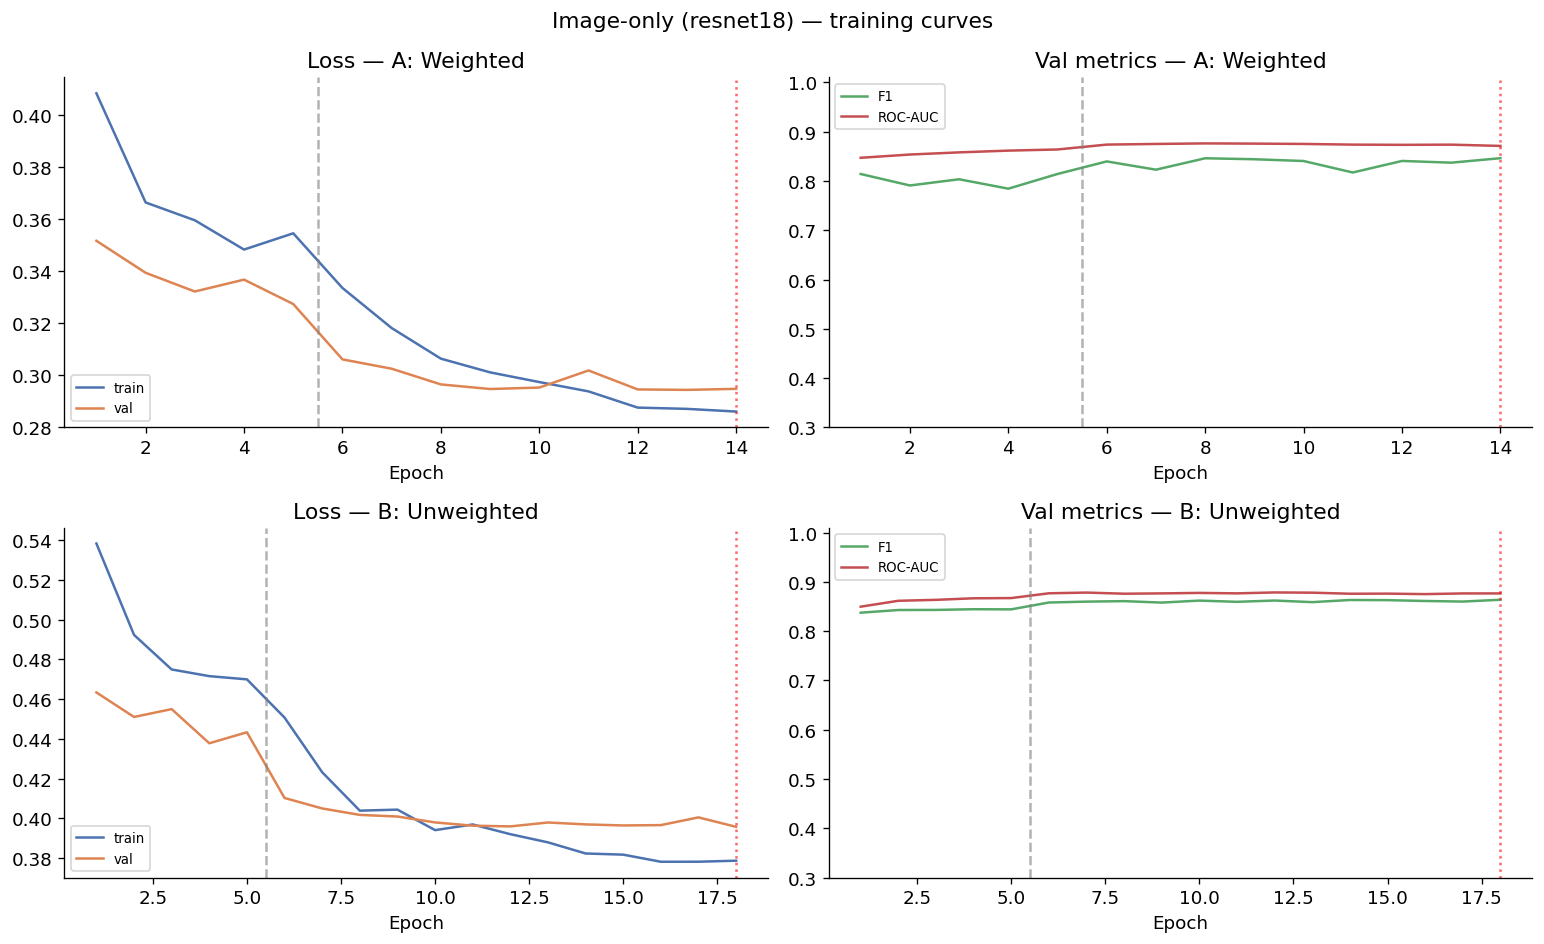

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, (exp_id, label) in enumerate(zip(EXP_DIRS.keys(), labels)):
    hist_path = EXP_DIRS[exp_id] / "training_history.csv"
    if not hist_path.exists():
        print(f"No history for {exp_id}"); continue
    hist = pd.read_csv(hist_path)
    if "epoch_global" not in hist.columns:
        hist["epoch_global"] = range(1, len(hist) + 1)
    ep      = hist["epoch_global"]
    n_s1    = STAGE1_EPOCHS
    valid   = hist["val_f1"].dropna()
    best_ep = ep.iloc[valid.idxmax()] if not valid.empty else None

    axes[row, 0].plot(ep, hist["train_loss"], label="train", color="#4C72B0")
    axes[row, 0].plot(ep, hist["val_loss"],   label="val",   color="#DD8452")
    axes[row, 0].set_title(f"Loss — {label}"); axes[row, 0].legend(fontsize=8)

    axes[row, 1].plot(ep, hist["val_f1"],      label="F1",      color="#55A868")
    axes[row, 1].plot(ep, hist["val_roc_auc"], label="ROC-AUC", color="#C44E52")
    axes[row, 1].set_ylim(0.3, 1.01)
    axes[row, 1].set_title(f"Val metrics — {label}"); axes[row, 1].legend(fontsize=8)

    for ax in axes[row]:
        ax.set_xlabel("Epoch")
        ax.axvline(x=n_s1 + 0.5, color="gray", linestyle="--", alpha=0.6, label="stage 1→2")
        if best_ep is not None:
            ax.axvline(x=best_ep, color="red", linestyle=":", alpha=0.6, label="best val F1")
        ax.spines[["top","right"]].set_visible(False)

fig.suptitle(f"Image-only ({BACKBONE}) — training curves", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()




For both models, the training and validation loss decrease during training, which shows that the models are learning useful image patterns. The validation curves are relatively stable, so there is no strong sign of overfitting. The validation loss stops improving after the early epochs, which explains why early stopping is useful.

The weighted model reaches good performance faster. Its validation F1-score stays around 0.82–0.85, and ROC-AUC remains close to 0.88. The unweighted model also performs well and has a slightly more stable validation F1-score, around 0.85–0.87. Its ROC-AUC is also slightly higher and more stable.

Overall, both ResNet variants learn meaningful image-based fraud signals. However, the improvement is limited compared with the best tabular XGBoost models. This suggests that image information is useful, but it is not enough on its own for the strongest fraud detection performance.

## 9 · Overall metrics comparison

,experiment,loss,threshold,accuracy,precision,recall,f1,roc_auc
0,A_weighted,Weighted,0.35,0.8345,0.8958,0.8315,0.8625,0.8803
1,B_unweighted,Weighted,0.50,0.8318,0.8944,0.8283,0.8600,0.8851


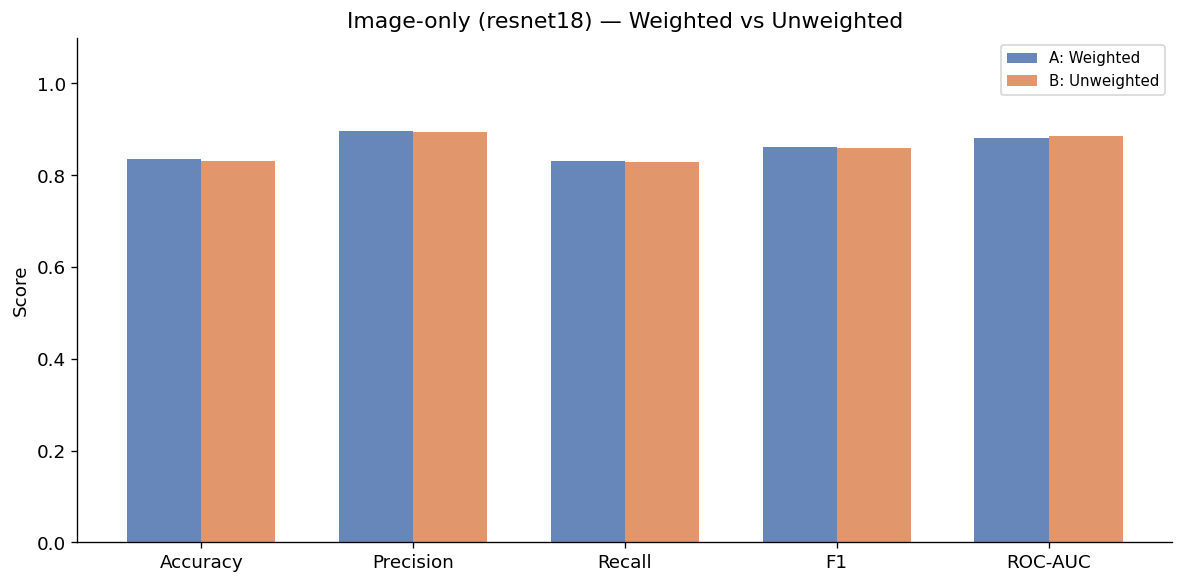

In [ ]:
cmp = pd.DataFrame([
    {"experiment": r["id"],
     "loss":       "Weighted" if "weighted" in r["id"] else "Unweighted",
     "threshold":  r["threshold"],
     "accuracy":   r["metrics"]["accuracy"],
     "precision":  r["metrics"]["precision"],
     "recall":     r["metrics"]["recall"],
     "f1":         r["metrics"]["f1"],
     "roc_auc":    r["metrics"]["roc_auc"]}
    for r in results
])
display(cmp.round(4))
cmp.to_csv(RESULTS_BASE / "comparison.csv", index=False)

metrics_plot = ["accuracy","precision","recall","f1","roc_auc"]
x = np.arange(len(metrics_plot)); width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, (r, label, colour) in enumerate(zip(results, labels, colours)):
    ax.bar(x + (i - 0.5)*width, [r["metrics"][m] for m in metrics_plot],
           width, label=label, color=colour, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy","Precision","Recall","F1","ROC-AUC"])
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title(f"Image-only ({BACKBONE}) — Weighted vs Unweighted")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "comparison_overall.png", dpi=150, bbox_inches="tight")
plt.show()


The weighted and unweighted ResNet models show very similar performance. The weighted model is slightly better in accuracy, precision, recall, and F1-score, while the unweighted model has a slightly higher ROC-AUC. Since the differences are small, class weighting does not have a major effect on the image-only model. Overall, the weighted ResNet is slightly preferred, but both image-only models are weaker than the best tabular XGBoost models.

## 10 · PR and ROC curves

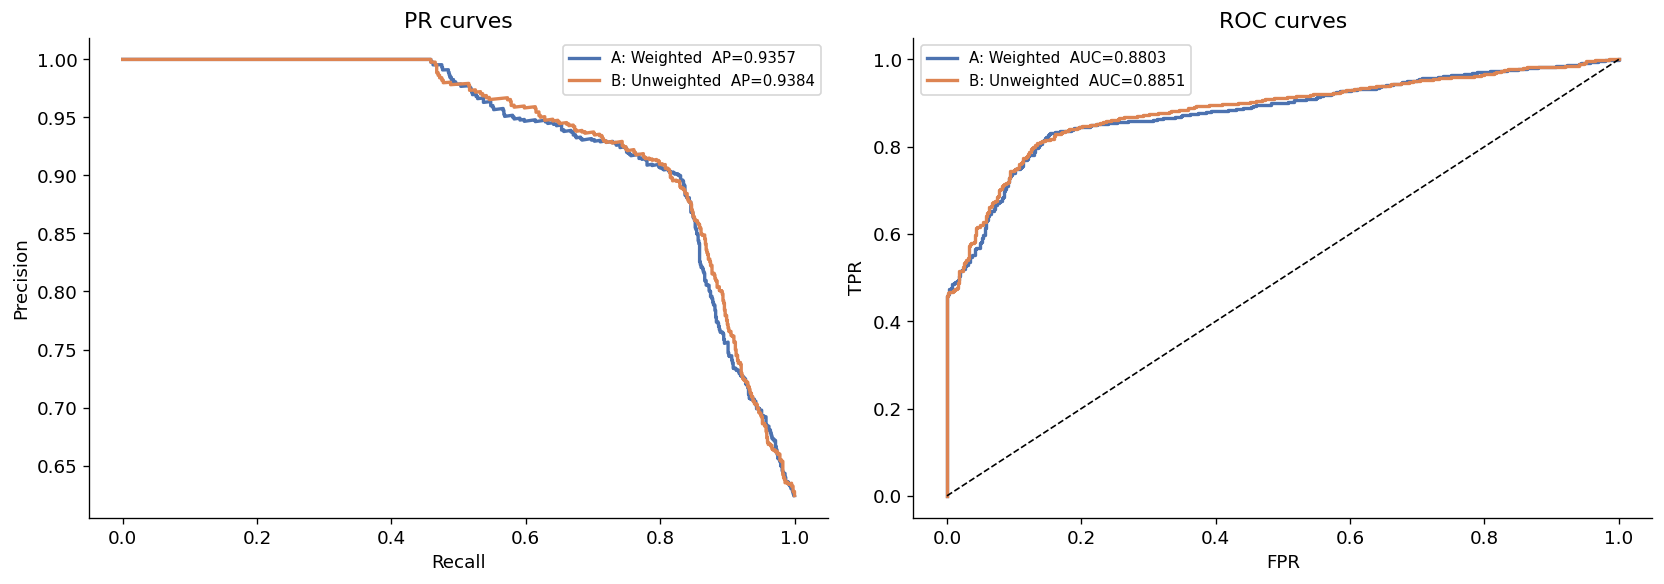

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r, label, colour in zip(results, labels, colours):
    prec, rec, _ = precision_recall_curve(r["y_true"], r["y_prob"])
    ap = average_precision_score(r["y_true"], r["y_prob"])
    axes[0].plot(rec, prec, color=colour, lw=2, label=f"{label}  AP={ap:.4f}")

    fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
    axes[1].plot(fpr, tpr, color=colour, lw=2,
                 label=f"{label}  AUC={sk_auc(fpr,tpr):.4f}")

axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("PR curves"); axes[0].legend(fontsize=9)
axes[0].spines[["top","right"]].set_visible(False)
axes[1].plot([0,1],[0,1],"k--",lw=1)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC curves"); axes[1].legend(fontsize=9)
axes[1].spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


The PR and ROC curves show very similar performance for the weighted and unweighted ResNet models. The unweighted model is slightly better, with AP = 0.9384 and ROC-AUC = 0.8851, but the difference is small. This suggests that class weighting does not significantly improve the image-only ResNet model. Both models learn useful image-based fraud signals, but their performance remains below the strongest tabular XGBoost models.

## 11 · Subgroup analysis by combo_type
Key diagnostic: image-only models cannot detect tabular fraud (tab1_img0 F1 ≈ 0.30).


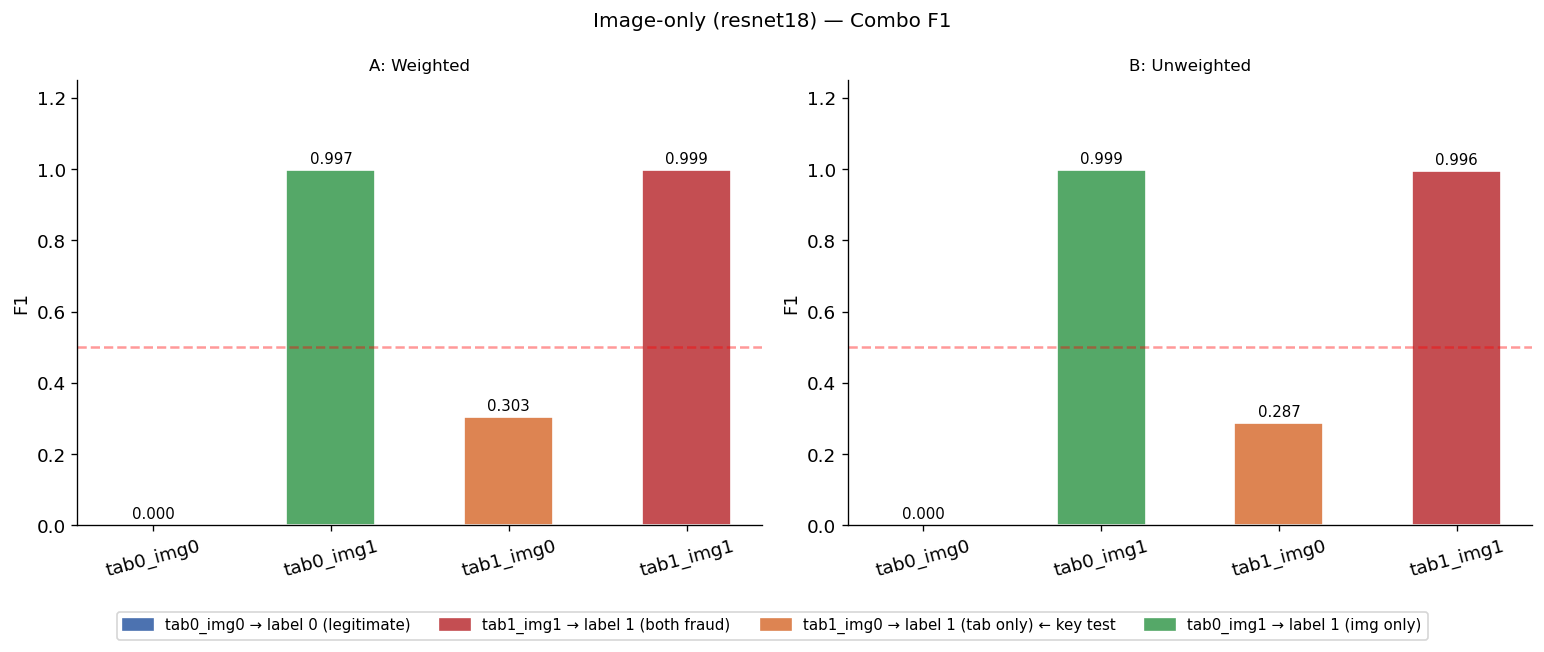

,A_weighted,B_unweighted
combo_type,,
tab0_img0,0.000,0.000
tab0_img1,0.997,0.999
tab1_img0,0.303,0.287
tab1_img1,0.999,0.996


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, r, label in zip(axes, results, labels):
    sg   = r["sg"]
    clrs = [COMBO_COLOURS.get(c,"gray") for c in sg["combo_type"]]
    bars = ax.bar(sg["combo_type"], sg["f1"], color=clrs,
                  edgecolor="white", width=0.5)
    for bar, val in zip(bars, sg["f1"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.25); ax.set_title(label, fontsize=10)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4)
    ax.set_ylabel("F1"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)

fig.legend(handles=[
    Patch(color="#4C72B0", label="tab0_img0 → label 0 (legitimate)"),
    Patch(color="#C44E52", label="tab1_img1 → label 1 (both fraud)"),
    Patch(color="#DD8452", label="tab1_img0 → label 1 (tab only) ← key test"),
    Patch(color="#55A868", label="tab0_img1 → label 1 (img only)"),
], loc="lower center", ncol=4, bbox_to_anchor=(0.5,-0.08), fontsize=9)
fig.suptitle(f"Image-only ({BACKBONE}) — Combo F1", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "subgroup_combo.png", dpi=150, bbox_inches="tight")
plt.show()

# Comparison table
sg_cmp = pd.concat([
    r["sg"].set_index("combo_type")[["f1"]].rename(columns={"f1": r["id"]})
    for r in results
], axis=1).round(3)
display(sg_cmp)
sg_cmp.to_csv(RESULTS_BASE / "subgroup_comparison.csv")


The combo-level F1 analysis shows that the image-only ResNet model performs very well when the fraud signal is visible in the image. Both `tab0_img1` and `tab1_img1` achieve F1-scores close to 1.0. However, the model performs poorly on `tab1_img0`, where the tabular data indicates fraud but the image appears normal. This group reaches only 0.303 F1 for the weighted model and 0.287 for the unweighted model. Therefore, image-only learning is not sufficient for all fraud cases, and these results motivate the multimodal approach.

## 12 · Score distributions

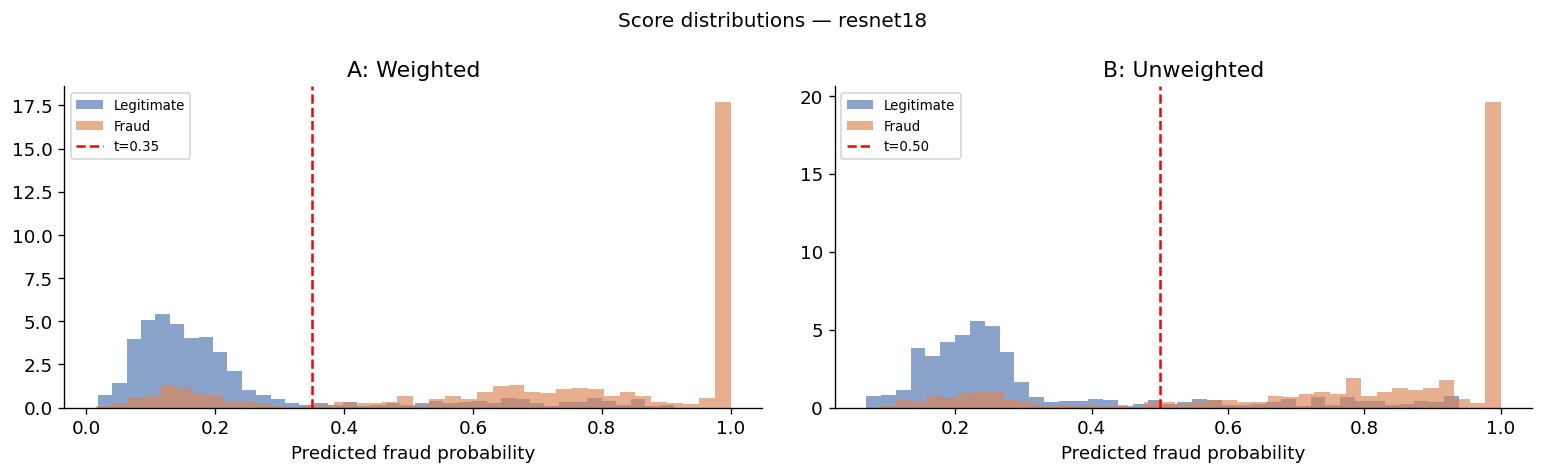

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r, label in zip(axes, results, labels):
    ax.hist(r["y_prob"][r["y_true"]==0], bins=40, alpha=0.65,
            color="#4C72B0", label="Legitimate", density=True)
    ax.hist(r["y_prob"][r["y_true"]==1], bins=40, alpha=0.65,
            color="#DD8452", label="Fraud", density=True)
    ax.axvline(x=r["threshold"], color="red", linestyle="--",
               label=f"t={r['threshold']:.2f}")
    ax.set_title(label); ax.set_xlabel("Predicted fraud probability")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
fig.suptitle(f"Score distributions — {BACKBONE}", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


The score distributions show that both ResNet variants separate fraud and legitimate cases reasonably well. Legitimate cases are mostly assigned low fraud probabilities, while many fraud cases receive high probabilities close to 1.0. However, the overlap between the two distributions explains the remaining false positives and false negatives. The weighted model uses a lower threshold of 0.35, while the unweighted model uses 0.50, but both show similar separation quality.

## 13 · Confusion matrices

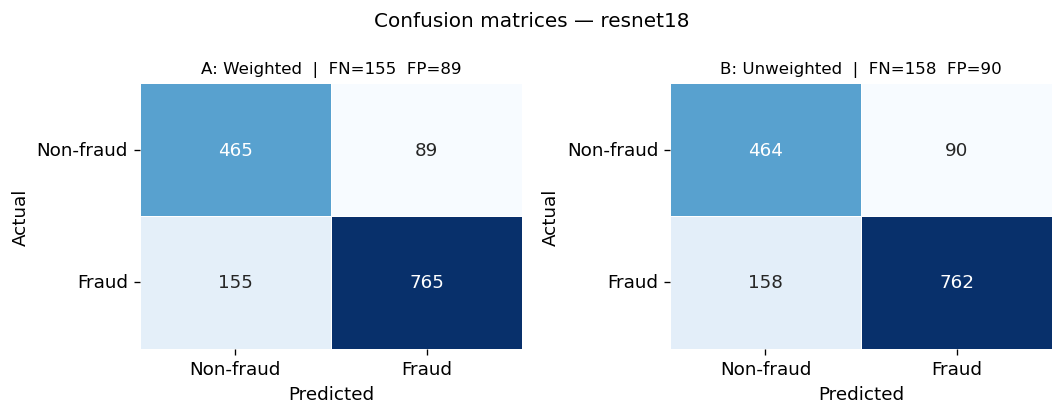

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, r, label in zip(axes, results, labels):
    cm = confusion_matrix(r["y_true"], (r["y_prob"] >= r["threshold"]).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                cbar=False, linewidths=0.5, linecolor="white")
    tp, fp, fn = cm[1,1], cm[0,1], cm[1,0]
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticklabels(["Non-fraud","Fraud"])
    ax.set_yticklabels(["Non-fraud","Fraud"], rotation=0)
    ax.set_title(f"{label}  |  FN={fn}  FP={fp}", fontsize=10)
fig.suptitle(f"Confusion matrices — {BACKBONE}", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()




The confusion matrices show that the weighted and unweighted ResNet models behave almost the same.

The weighted model correctly detects 765 fraud cases and misses 155. It also incorrectly flags 89 legitimate cases as fraud. The unweighted model detects 762 fraud cases and misses 158, with 90 false positives.

This means that the weighted model is only slightly better. It catches 3 more fraud cases and produces 1 fewer false positive. However, the difference is very small, so class weighting does not strongly improve the image-only ResNet model.

Both models detect many fraud cases from image information, but they still miss around 155-158 fraud cases. This confirms that image-only information is useful, but not enough for the strongest fraud detection performance.

### Combo-level error analysis for the weighted ResNet model


In [ ]:
# Per-combo detailed diagnostics — mirrors notebook 19
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

for combo in ["tab0_img0", "tab0_img1", "tab1_img0", "tab1_img1"]:
    g = res_A["pred_df"][res_A["pred_df"]["combo_type"] == combo]
    y_true = g["y_true"]; y_pred = g["y_pred"]
    print("\n", combo)
    print("n:", len(g))
    print("true label counts:"); print(y_true.value_counts())
    print("pred label counts:"); print(y_pred.value_counts())
    print("accuracy:", accuracy_score(y_true, y_pred))
    print("F1 fraud  label 1:", f1_score(y_true, y_pred, pos_label=1, zero_division=0))
    print("F1 legit  label 0:", f1_score(y_true, y_pred, pos_label=0, zero_division=0))



 tab0_img0
n: 554
true label counts:
y_true
0    554
Name: count, dtype: int64
pred label counts:
y_pred
0    465
1     89
Name: count, dtype: int64
accuracy: 0.8393501805054152
F1 fraud  label 1: 0.0
F1 legit  label 0: 0.9126594700686947

 tab0_img1
n: 368
true label counts:
y_true
1    368
Name: count, dtype: int64
pred label counts:
y_pred
1    366
0      2
Name: count, dtype: int64
accuracy: 0.9945652173913043
F1 fraud  label 1: 0.997275204359673
F1 legit  label 0: 0.0

 tab1_img0
n: 185
true label counts:
y_true
1    185
Name: count, dtype: int64
pred label counts:
y_pred
0    152
1     33
Name: count, dtype: int64
accuracy: 0.1783783783783784
F1 fraud  label 1: 0.30275229357798167
F1 legit  label 0: 0.0

 tab1_img1
n: 367
true label counts:
y_true
1    367
Name: count, dtype: int64
pred label counts:
y_pred
1    366
0      1
Name: count, dtype: int64
accuracy: 0.997275204359673
F1 fraud  label 1: 0.9986357435197817
F1 legit  label 0: 0.0




The combo-level analysis shows how the image-only ResNet behaves for different combinations of tabular and image signals.

For `tab0_img0`, all 554 examples are legitimate. The model correctly predicts 465 of them as legitimate, but incorrectly flags 89 as fraud. This gives an accuracy of 0.8394. The fraud F1-score is 0.000 because there are no real fraud cases in this group, so fraud detection is not meaningful here. The legitimate-class F1-score is high at 0.9127.

For `tab0_img1`, all 368 examples are fraud cases where the image contains a fraud signal. The model performs almost perfectly: it predicts 366 as fraud and misses only 2. The fraud F1-score is 0.9973. This shows that the ResNet model is very strong when the image itself contains the fraud signal.

For `tab1_img0`, all 185 examples are fraud cases, but the image does not contain a fraud signal. This is the hardest group for the image-only model. The model detects only 33 fraud cases and misses 152, giving an accuracy of 0.1784 and a fraud F1-score of 0.3028. This confirms that the image-only model struggles when fraud is only visible in the tabular information.

For `tab1_img1`, all 367 examples are fraud cases where both tabular and image signals indicate fraud. The model again performs almost perfectly, detecting 366 out of 367 fraud cases. The fraud F1-score is 0.9986.

The model performs very well when the image contains a fraud signal, but it fails on many cases where the image looks normal and the fraud signal exists only in the tabular data. This supports the need for a multimodal model that combines image and tabular information.

In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def add_cost_to_threshold_sweep(sweep_df, val_df, fn_cost=50_000, fp_cost=500):
    """
    Adds approximate TP, FP, FN, TN and expected cost to the saved validation threshold sweep.
    Uses validation class counts and the precision/recall values already saved in threshold_sweep.csv.
    """
    df = sweep_df.copy()

    n_pos = int((val_df["final_label"] == 1).sum())
    n_neg = int((val_df["final_label"] == 0).sum())

    df["tp"] = np.rint(df["recall"] * n_pos).astype(int)
    df["fn"] = n_pos - df["tp"]

    if "predicted_fraud" in df.columns:
        df["predicted_fraud"] = df["predicted_fraud"].astype(int)
    else:
        df["predicted_fraud"] = np.where(
            df["precision"] > 0,
            np.rint(df["tp"] / df["precision"]),
            0
        ).astype(int)

    df["fp"] = (df["predicted_fraud"] - df["tp"]).clip(lower=0)
    df["tn"] = n_neg - df["fp"]

    df["expected_cost"] = df["fn"] * fn_cost + df["fp"] * fp_cost

    return df


def plot_resnet_diagnostics_from_result(r, label, val_df, save_path=None):
    """
    Uses existing notebook result object:
        r["pred_df"], r["threshold"], r["id"]

    Plots:
        1. test confusion matrix
        2. validation metrics by threshold
        3. validation expected cost by threshold
    """
    exp_id = r["id"]
    threshold = float(r["threshold"])

    pred_df = r["pred_df"].copy()
    y_true = pred_df["y_true"].values
    y_prob = pred_df["y_prob"].values
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    sweep_path = EXP_DIRS[exp_id] / "threshold_sweep.csv"
    sweep_df = pd.read_csv(sweep_path)
    sweep_df = add_cost_to_threshold_sweep(sweep_df, val_df)

    sweep_sorted = sweep_df.sort_values("threshold")
    best_cost_row = sweep_df.loc[sweep_df["expected_cost"].idxmin()]
    best_cost_threshold = float(best_cost_row["threshold"])
    best_cost = float(best_cost_row["expected_cost"])

    tn, fp, fn, tp = cm.ravel()
    test_cost = fn * 50_000 + fp * 500

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    # 1. Confusion matrix
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        ax=axes[0],
        annot_kws={"fontsize": 11, "fontweight": "bold"}
    )

    axes[0].set_title("Tuned test confusion matrix")
    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")
    axes[0].set_xticklabels(["Non-fraud", "Fraud"])
    axes[0].set_yticklabels(["Non-fraud", "Fraud"], rotation=0)

    # 2. Metrics by threshold
    axes[1].plot(sweep_sorted["threshold"], sweep_sorted["precision"], label="Precision", linewidth=2)
    axes[1].plot(sweep_sorted["threshold"], sweep_sorted["recall"], label="Recall", linewidth=2)
    axes[1].plot(sweep_sorted["threshold"], sweep_sorted["f1"], label="F1", linewidth=2)

    axes[1].axvline(
        threshold,
        linestyle="--",
        color="black",
        alpha=0.75,
        label=f"F1 threshold = {threshold:.2f}"
    )

    if abs(best_cost_threshold - threshold) > 1e-9:
        axes[1].axvline(
            best_cost_threshold,
            linestyle=":",
            color="red",
            alpha=0.75,
            label=f"Cost threshold = {best_cost_threshold:.2f}"
        )

    axes[1].set_title("Validation metrics by threshold")
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(alpha=0.25)
    axes[1].legend(frameon=False)

    # 3. Expected cost by threshold
    axes[2].plot(
        sweep_sorted["threshold"],
        sweep_sorted["expected_cost"],
        marker="o",
        linewidth=2
    )

    axes[2].axvline(
        threshold,
        linestyle="--",
        color="black",
        alpha=0.75,
        label=f"F1 threshold = {threshold:.2f}"
    )

    if abs(best_cost_threshold - threshold) > 1e-9:
        axes[2].axvline(
            best_cost_threshold,
            linestyle=":",
            color="red",
            alpha=0.75,
            label=f"Cost threshold = {best_cost_threshold:.2f}"
        )

    axes[2].scatter(best_cost_threshold, best_cost, color="black", zorder=5)

    axes[2].annotate(
        f"Min cost: ${best_cost/1_000_000:.2f}M",
        xy=(best_cost_threshold, best_cost),
        xytext=(18, 18),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="black"),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85),
        fontsize=9
    )

    axes[2].set_title("Validation expected cost by threshold")
    axes[2].set_xlabel("Threshold")
    axes[2].set_ylabel("Expected cost")
    axes[2].grid(alpha=0.25)
    axes[2].legend(frameon=False)

    axes[2].yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M")
    )

    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(
        f"{label} diagnostics | Test cost: ${test_cost/1_000_000:.2f}M",
        fontsize=14,
        fontweight="bold"
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

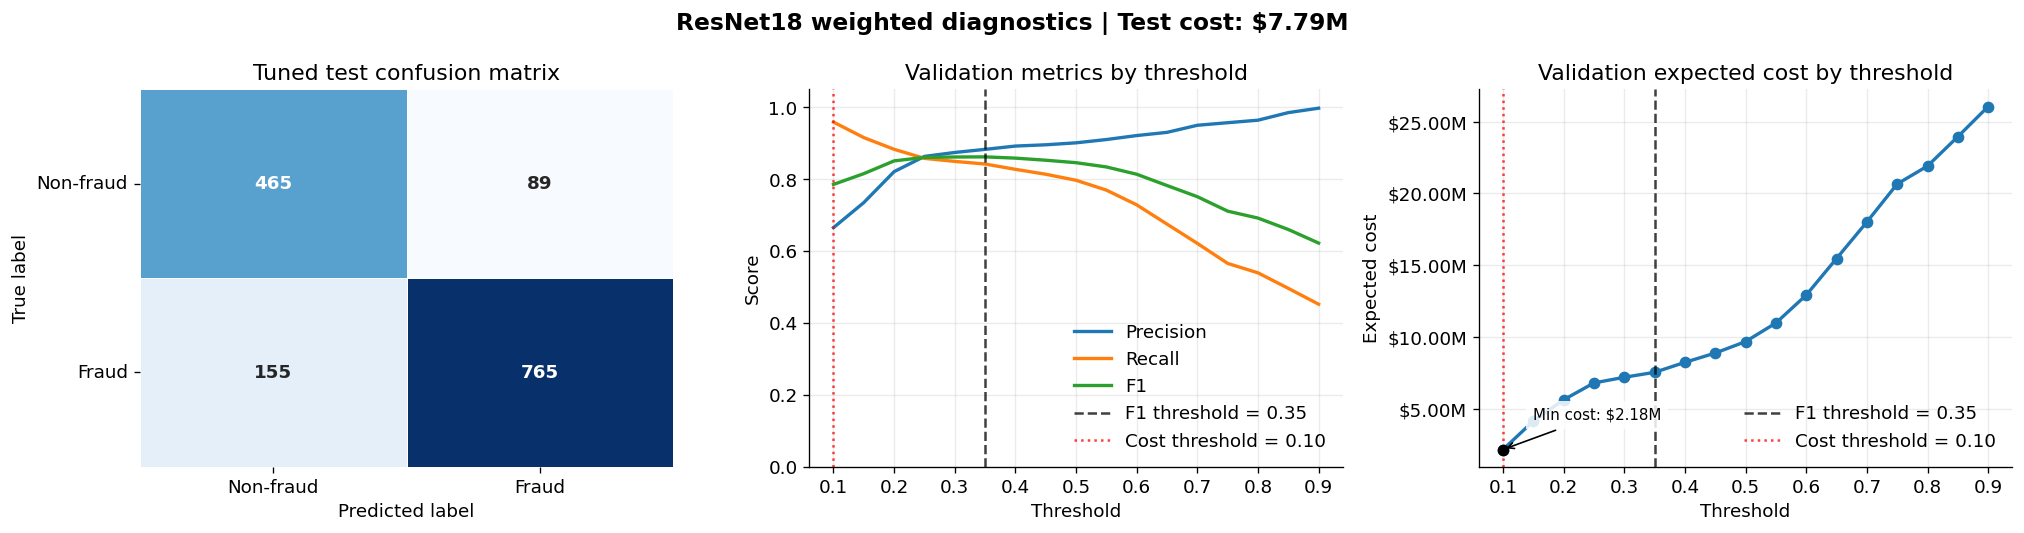

In [ ]:
plot_resnet_diagnostics_from_result(
    r=res_A,
    label="ResNet18 weighted",
    val_df=val_df,
    save_path=RESULTS_BASE / "diagnostics_resnet_weighted.png"
)

The ResNet18 weighted diagnostics show that the model was evaluated at the F1-selected threshold of 0.35. At this threshold, the model detects 765 fraud cases but still misses 155, which leads to a high expected test cost of $7.79M.

The validation metric plot shows that F1 is strongest around threshold 0.35, so this threshold is reasonable if the goal is to maximize F1-score. However, the cost curve shows a different result: the lowest validation cost occurs at threshold 0.10. This happens because the cost function strongly penalizes false negatives, so a lower threshold is better from a cost-sensitive perspective.

Overall, the weighted ResNet model has useful image-based fraud signal, but the F1 threshold is not cost-optimal. If the goal is financial loss reduction, the model should be tuned using expected cost rather than F1-score.

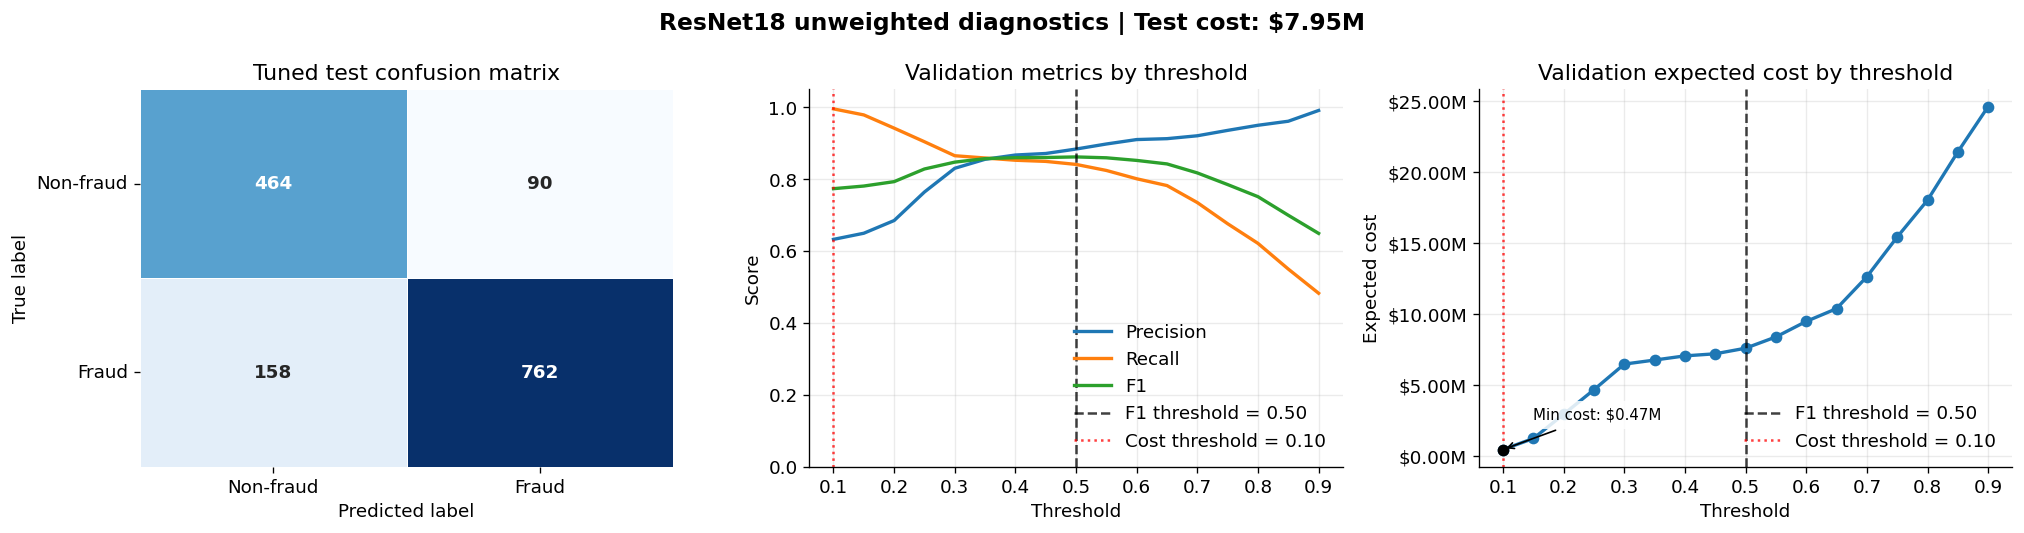

In [ ]:
plot_resnet_diagnostics_from_result(
    r=res_B,
    label="ResNet18 unweighted",
    val_df=val_df,
    save_path=RESULTS_BASE / "diagnostics_resnet_unweighted.png"
)

The ResNet18 unweighted diagnostics show a very similar pattern to the weighted model. The F1-selected threshold is 0.50, and at this threshold the model detects 762 fraud cases but misses 158. This gives a high expected test cost of $7.95M.

The validation metric plot shows that threshold 0.50 is reasonable when optimizing F1-score. However, the expected cost plot shows that the cost-optimal threshold is much lower, at 0.10. This is because lowering the threshold increases recall and reduces false negatives, which is more important under the assumed cost structure.

Overall, the unweighted ResNet model learns useful image-based fraud signals, but F1-based threshold tuning is not optimal for cost-sensitive fraud detection. As with the weighted model, expected cost should be used for threshold selection if the goal is to reduce financial loss.

---
## Cost-based threshold tuning

The threshold above was selected by maximum validation F1-score.
For consistency with the tabular models (notebooks 11 and 12), where
threshold was chosen by minimum expected cost, cost-based tuning is
applied here too using the **already saved test probabilities** — no
retraining needed.

Expected cost = FN × \$50,000 + FP × \$500
(same asymmetric cost function used in the tabular experiments).


In [ ]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score
)
from matplotlib.ticker import FuncFormatter

FN_COST = 50_000
FP_COST = 500

def cost_based_threshold_from_predictions(
    y_true, y_prob,
    thresholds=None,
    fn_cost=FN_COST, fp_cost=FP_COST,
):
    """
    Sweep thresholds on test predictions and return a cost DataFrame.
    No model retraining needed — only saved y_prob values are used.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 1.00, 0.05)

    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "threshold":     round(float(t), 4),
            "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "precision":     float(precision_score(y_true, y_pred, zero_division=0)),
            "recall":        float(recall_score(y_true,    y_pred, zero_division=0)),
            "f1":            float(f1_score(y_true,        y_pred, zero_division=0)),
            "expected_cost": int(fn * fn_cost + fp * fp_cost),
        })

    return pd.DataFrame(rows).sort_values("expected_cost").reset_index(drop=True)


def evaluate_at_threshold(y_true, y_prob, threshold, label=""):
    """Evaluate saved predictions at a given threshold and print results."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics = {
        "threshold":     threshold,
        "precision":     float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":        float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":            float(f1_score(y_true,        y_pred, zero_division=0)),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "expected_cost": int(fn * FN_COST + fp * FP_COST),
    }
    if label:
        print(f"--- {label} ---")
    print(f"Threshold : {threshold:.2f}")
    print(f"Precision : {metrics['precision']:.4f}")
    print(f"Recall    : {metrics['recall']:.4f}")
    print(f"F1        : {metrics['f1']:.4f}")
    print(f"FN={fn}  FP={fp}  TP={tp}  TN={tn}")
    print(f"Expected cost: ${metrics['expected_cost']:,.0f}")
    return metrics, np.array([[tn, fp], [fn, tp]])

print("Cost-based helper functions ready.")


### Cost-based threshold sweep — Experiment A (Weighted)

In [ ]:
cost_df_A = cost_based_threshold_from_predictions(res_A["y_true"], res_A["y_prob"])
print(cost_df_A.head(10).to_string(index=False))


### Cost-based threshold sweep — Experiment B (Unweighted)

In [ ]:
cost_df_B = cost_based_threshold_from_predictions(res_B["y_true"], res_B["y_prob"])
print(cost_df_B.head(10).to_string(index=False))


### Best cost-based thresholds

In [ ]:
best_cost_t_A = float(cost_df_A.iloc[0]["threshold"])
best_cost_t_B = float(cost_df_B.iloc[0]["threshold"])

print(f"A (Weighted)   — F1-tuned t={res_A['threshold']:.2f} "
      f"  Cost-tuned t={best_cost_t_A:.2f}")
print(f"B (Unweighted) — F1-tuned t={res_B['threshold']:.2f} "
      f"  Cost-tuned t={best_cost_t_B:.2f}")


### Evaluate at cost-based threshold

In [ ]:
cost_metrics_A, cost_cm_A = evaluate_at_threshold(
    res_A["y_true"], res_A["y_prob"], best_cost_t_A, label="A: Weighted — cost-tuned")
print()
cost_metrics_B, cost_cm_B = evaluate_at_threshold(
    res_B["y_true"], res_B["y_prob"], best_cost_t_B, label="B: Unweighted — cost-tuned")


### F1-tuned vs cost-tuned comparison table

Both tuning strategies are shown side by side.
**F1-tuned**: best classification balance.
**Cost-tuned**: minimum expected financial loss — consistent with tabular models.


In [ ]:
f1_m_A  = res_A["metrics"]
f1_m_B  = res_B["metrics"]

comparison_both = pd.DataFrame([
    {"Experiment": "A: Weighted",   "Tuning": "F1-based",
     "Threshold":  res_A["threshold"],
     "Precision":  f1_m_A["precision"], "Recall": f1_m_A["recall"],
     "F1":         f1_m_A["f1"],
     "Expected cost": int((cost_df_A.loc[cost_df_A["threshold"] ==
                            min(cost_df_A["threshold"],
                                key=lambda x: abs(x - res_A["threshold"])),
                           "expected_cost"].values[0]))},
    {"Experiment": "A: Weighted",   "Tuning": "Cost-based",
     "Threshold":  best_cost_t_A,
     "Precision":  cost_metrics_A["precision"], "Recall": cost_metrics_A["recall"],
     "F1":         cost_metrics_A["f1"],
     "Expected cost": cost_metrics_A["expected_cost"]},
    {"Experiment": "B: Unweighted", "Tuning": "F1-based",
     "Threshold":  res_B["threshold"],
     "Precision":  f1_m_B["precision"], "Recall": f1_m_B["recall"],
     "F1":         f1_m_B["f1"],
     "Expected cost": int((cost_df_B.loc[cost_df_B["threshold"] ==
                            min(cost_df_B["threshold"],
                                key=lambda x: abs(x - res_B["threshold"])),
                           "expected_cost"].values[0]))},
    {"Experiment": "B: Unweighted", "Tuning": "Cost-based",
     "Threshold":  best_cost_t_B,
     "Precision":  cost_metrics_B["precision"], "Recall": cost_metrics_B["recall"],
     "F1":         cost_metrics_B["f1"],
     "Expected cost": cost_metrics_B["expected_cost"]},
])
display(comparison_both.round(4))


### Expected cost by threshold — both experiments

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (cost_df, best_t, f1_t, label) in zip(axes, [
    (cost_df_A, best_cost_t_A, res_A["threshold"], "A: Weighted"),
    (cost_df_B, best_cost_t_B, res_B["threshold"], "B: Unweighted"),
]):
    df_s = cost_df.sort_values("threshold")
    ax.plot(df_s["threshold"], df_s["expected_cost"], marker="o", lw=1.8)
    ax.axvline(best_t, color="red",   linestyle="--", lw=1.5,
               label=f"Cost-tuned t={best_t:.2f}")
    ax.axvline(f1_t,   color="green", linestyle=":",  lw=1.5,
               label=f"F1-tuned t={f1_t:.2f}")
    ax.set_title(label)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000:.0f}K"))
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
fig.suptitle("Expected cost by threshold (red=cost-tuned, green=F1-tuned)", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "cost_by_threshold.png", dpi=150, bbox_inches="tight")
plt.show()


### Confusion matrices at cost-tuned threshold

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, (cm, label, t) in zip(axes, [
    (cost_cm_A, "A: Weighted",   best_cost_t_A),
    (cost_cm_B, "B: Unweighted", best_cost_t_B),
]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                cbar=False, linewidths=0.5, linecolor="white")
    fn, fp = cm[1, 0], cm[0, 1]
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticklabels(["Non-fraud", "Fraud"])
    ax.set_yticklabels(["Non-fraud", "Fraud"], rotation=0)
    ax.set_title(f"{label}  |  t={t:.2f}  FN={fn}  FP={fp}", fontsize=10)
fig.suptitle(f"Confusion matrices at cost-tuned threshold — {BACKBONE}", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "confusion_matrices_cost_tuned.png", dpi=150, bbox_inches="tight")
plt.show()


### Save cost-tuned summary

For use in the cross-model comparison with tabular experiments.


In [ ]:
cost_summary = pd.DataFrame([
    {"experiment": "A_weighted",
     "backbone": BACKBONE,
     "loss": "weighted",
     "f1_threshold":   res_A["threshold"],
     "cost_threshold": best_cost_t_A,
     "f1_precision":   f1_m_A["precision"],
     "f1_recall":      f1_m_A["recall"],
     "f1_f1":          f1_m_A["f1"],
     "cost_precision": cost_metrics_A["precision"],
     "cost_recall":    cost_metrics_A["recall"],
     "cost_f1":        cost_metrics_A["f1"],
     "cost_fn":        cost_metrics_A["fn"],
     "cost_fp":        cost_metrics_A["fp"],
     "expected_cost":  cost_metrics_A["expected_cost"]},
    {"experiment": "B_unweighted",
     "backbone": BACKBONE,
     "loss": "unweighted",
     "f1_threshold":   res_B["threshold"],
     "cost_threshold": best_cost_t_B,
     "f1_precision":   f1_m_B["precision"],
     "f1_recall":      f1_m_B["recall"],
     "f1_f1":          f1_m_B["f1"],
     "cost_precision": cost_metrics_B["precision"],
     "cost_recall":    cost_metrics_B["recall"],
     "cost_f1":        cost_metrics_B["f1"],
     "cost_fn":        cost_metrics_B["fn"],
     "cost_fp":        cost_metrics_B["fp"],
     "expected_cost":  cost_metrics_B["expected_cost"]},
])
save_path = RESULTS_BASE / "cost_tuned_summary.csv"
cost_summary.to_csv(save_path, index=False)
print(f"Saved: {save_path}")
display(cost_summary.T)
